In [2]:
#for reading files
import glob
import tifffile

#math computation and data organization
import numpy as np
import math
import scipy
from scipy.ndimage import binary_erosion, binary_fill_holes
from scipy import optimize
from scipy.optimize import curve_fit
import pandas as pd

# For loading bars
from tqdm.notebook import tqdm as tqdm

#For image plotting
import skimage.io

#For identifying aster center
from skimage.filters import threshold_otsu, gaussian, threshold_mean
from skimage.measure import regionprops
import cv2

#for fitting
from lmfit import minimize, Parameters, fit_report

#for image registration
from skimage.registration import phase_cross_correlation
import os

#Matplotlib plotting packages
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import patches
from matplotlib import gridspec

import seaborn as sns
sns.set_context("poster")
sns.set_style("ticks")

In [3]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # Use TrueType fonts for editable text in PDFs

In [4]:
######### gabe hacky styling to emulate some of PBoC Phillips lab style conventions, however hacky. tries to make easier for nigel++
## Styling
import matplotlib
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("poster")
# sns.set_style('ticks')

import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Set the property to save figures with text as text, not paths
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# default good PBoC colors
baseBlendColor=(224/255, 219/255, 209/255,1) # default background for plots
contrastColor=(209/255, 193/255, 171/255,1) # slightly darker tan for contrasts, e.g. in inset boxes
yellowTanHighlightBoxColor='#FEF0C6'
goodGreyGreenArrowColor='#CCD4C9'

### Griffin style invocation

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.path import Path
from matplotlib.patches import BoxStyle
from matplotlib.offsetbox import AnchoredText

def plotting_style(grid=False):
    """
    Sets the style to the publication style. To instantiate, simply call
    plotting_style() at the beginning of your script or notebook to force
    all matplotlib plots to adopt the scheme.

    Parameters
    ----------
    grid: bool
      If True, plots will have a thin, white grid in the background. Default
      is False.

    Returns
    -------
    colors: dict
      Returns a dictionary of the standard PBoC 2e color palette.
    """
    rc = {'axes.facecolor': '#E3DCD0',
#               'axes.spines.top': False,
#               'axes.spines.right': False,
#               'axes.spines.left': False,  # Ensure left spine is present
#               'axes.spines.bottom': False,  # Ensure bottom spine is present
#               'axes.spines.left': False, #{'color': '#E3DCD0', 'linewidth': 1.5},  # Set the spine color to the background color
#               'axes.spines.bottom': False, #{'color': '#E3DCD0', 'linewidth': 1.5},  # Set the spine color to the background color
          #'font.family': '/usr/share/fonts/truetype/LucidaSansOT.otf', #'LucidaSansOT.otf',
          'grid.linestyle': '-',
          'grid.linewidth': 0.5,
          'grid.alpha': 0.75,
          'grid.color': '#ffffff',
          'axes.grid': grid,
          'ytick.direction': 'in',
          'xtick.direction': 'in',
          'xtick.gridOn': grid,
          'ytick.gridOn': grid,
#               'ytick.major.width':8,
#               'xtick.major.width':8,
#               'ytick.major.size': 8,
#               'xtick.major.size': 8,
          'mathtext.fontset': 'stixsans',
          'mathtext.sf': 'sans',
          'legend.frameon': True,
          'legend.facecolor': '#FFEDCE',
          'figure.dpi': 150,
          'xtick.color': 'k',
          'ytick.color': 'k'
         }
    plt.rc('text.latex', preamble=r'\usepackage{sfmath}')
    plt.rc('mathtext', fontset='stixsans', sf='sans')
    sns.set_style('darkgrid', rc=rc)
    return color_palette()

def color_palette():
    """
    Returns a dictionary of the PBOC color palette
    """
    return {'green': '#7AA974', 'light_green': '#BFD598',
              'pale_green': '#DCECCB', 'yellow': '#EAC264',
              'light_yellow': '#F3DAA9', 'pale_yellow': '#FFEDCE',
              'blue': '#738FC1', 'light_blue': '#A9BFE3',
              'pale_blue': '#C9D7EE', 'red': '#D56C55', 'light_red': '#E8B19D',
              'pale_red': '#F1D4C9', 'purple': '#AB85AC',
              'light_purple': '#D4C2D9', 'dark_green':'#7E9D90', 'dark_brown':'#905426'}

def titlebox(
    ax, text, color, bgcolor=None, size=8, boxsize=0.1, pad=0.05, **kwargs
):
    """
    Sets a colored title box above the plot, spanning the entire plot width.

    Parameters
    ----------
    ax : matplotlib axis object
      The axis on which you want to add the titlebox.
    text: str
      The title tect
    bgcolor: str or None
      The background color of the title box. Default is no color (blank).
    size:  int
      Size of the text font
    boxsize: float [0, 1]
      Fraction of the total plot height to be occupied by the box. Default is 10% (0.1).
    pad: float
      The padding space between the title box and the top of the plot.

    """
    boxsize=str(boxsize * 100)  + '%'
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("top", size=boxsize, pad=pad)
    cax.get_xaxis().set_visible(False)
    cax.get_yaxis().set_visible(False)
    cax.spines["top"].set_visible(False)
    cax.spines["right"].set_visible(False)
#     cax.spines["bottom"].set_visible(False)
#     cax.spines["left"].set_visible(False)

#     cax.spines["bottom"].set_visible(True)
#     cax.spines["left"].set_visible(True)
#     cax.spines["left"].set_color("white")
#     cax.spines["bottom"].set_color("white")
#     cax.spines["bottom"].set_color("white")

#     cax.set_ticks_position('both')  # Adding ticks to both top and bottom
#     cax.yaxis.set_tick_params(direction='in', which='both', color='white')  # The bottom will maintain the default of 'out'


    plt.setp(cax.spines.values(), color=color)
    if bgcolor != None:
        cax.set_facecolor(bgcolor)
    else:
        cax.set_facecolor("white")
    at = AnchoredText(text, loc=10, frameon=False, prop=dict(size=size, color=color))
    cax.add_artist(at)


### Now actually call it
plotting_style()

import matplotlib.patheffects as pe
matplotlib.rcParams['axes.autolimit_mode'] = 'data'

In [61]:
pom1_7pt6 = pd.read_csv('../data/scaleOfGradCompare/redPom1digitize.csv')
pom1_7pt6 = pom1_7pt6.sort_values(by=["x"])
#make boxes
rectpts_7pt6 = np.array(pom1_7pt6['x'][:-1])+(np.array(pom1_7pt6['x'][1:])-np.array(pom1_7pt6['x'][:-1]))/2
rectlens_7pt6 = rectpts_7pt6[1:]-rectpts_7pt6[:-1]
#area under the curve
auc_7pt6 = np.sum(np.array(pom1_7pt6[' y'])[1:-1]*rectlens_7pt6) + np.array(pom1_7pt6[' y'])[0]*(rectpts_7pt6[0]-np.array(pom1_7pt6['x'])[0]) + np.array(pom1_7pt6[' y'])[-1]*(np.array(pom1_7pt6['x'])[-1]- rectpts_7pt6[-1])

pom1_9pt8 = pd.read_csv('../data/scaleOfGradCompare/greyPom1digitize.csv')
pom1_9pt8 = pom1_9pt8.sort_values(by=["x"])
#make boxes
rectpts_9pt8 = np.array(pom1_9pt8['x'][:-1])+(np.array(pom1_9pt8['x'][1:])-np.array(pom1_9pt8['x'][:-1]))/2
rectlens_9pt8 = rectpts_9pt8[1:]-rectpts_9pt8[:-1]
#area under the curve
auc_9pt8 = np.sum(np.array(pom1_9pt8[' y'])[1:-1]*rectlens_9pt8) + np.array(pom1_9pt8[' y'])[0]*(rectpts_9pt8[0]-np.array(pom1_9pt8['x'])[0]) + np.array(pom1_9pt8[' y'])[-1]*(np.array(pom1_9pt8['x'])[-1]- rectpts_9pt8[-1])

pom1_11pt5 = pd.read_csv('../data/scaleOfGradCompare/blackPom1digitize.csv')
pom1_11pt5 = pom1_11pt5.sort_values(by=["x"])
#make boxes
rectpts_11pt5 = np.array(pom1_11pt5['x'][:-1])+(np.array(pom1_11pt5['x'][1:])-np.array(pom1_11pt5['x'][:-1]))/2
rectlens_11pt5 = rectpts_11pt5[1:]-rectpts_11pt5[:-1]
#area under the curve
auc_11pt5 = np.sum(np.array(pom1_11pt5[' y'])[1:-1]*rectlens_11pt5) + np.array(pom1_11pt5[' y'])[0]*(rectpts_11pt5[0]-np.array(pom1_11pt5['x'])[0]) + np.array(pom1_11pt5[' y'])[-1]*(np.array(pom1_11pt5['x'])[-1]- rectpts_11pt5[-1])


In [62]:
auc_7pt6, auc_9pt8, auc_11pt5

(np.float64(2694.8773134027556),
 np.float64(2534.345860380316),
 np.float64(1838.6568499989453))

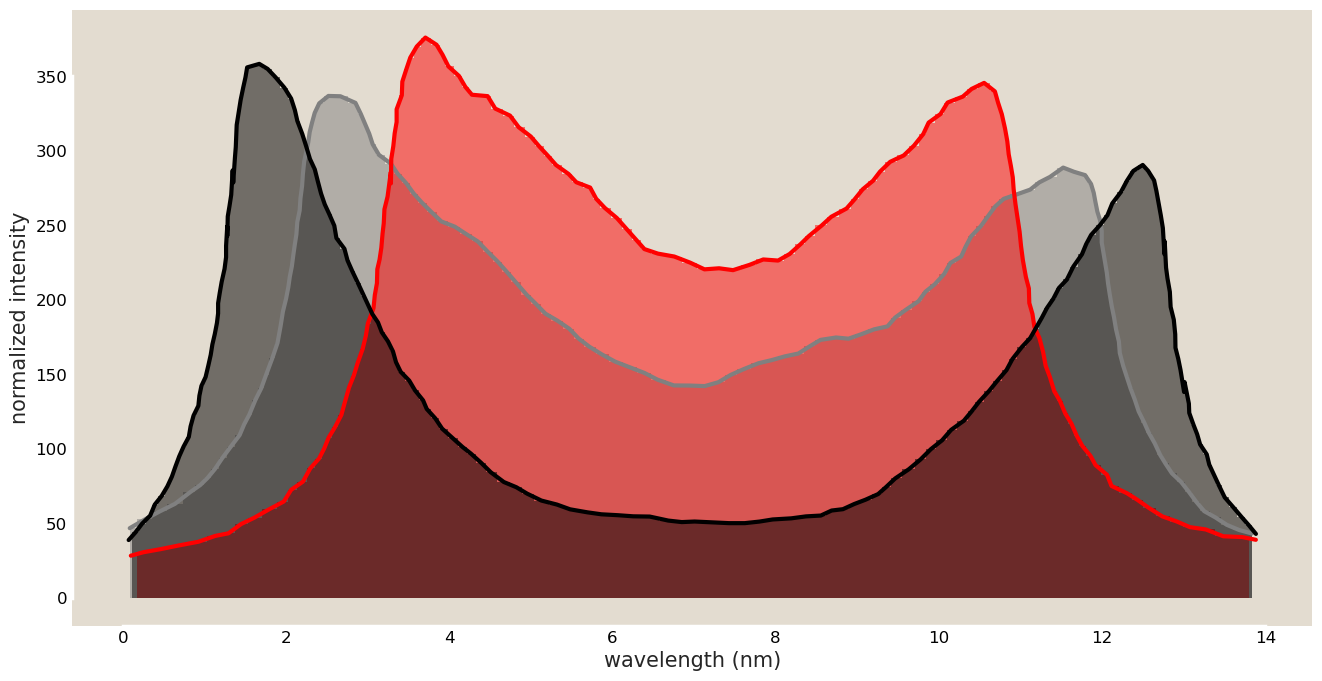

In [73]:
fig, ax = plt.subplots(figsize=(16, 8))
plt.plot(pom1_9pt8['x'], pom1_9pt8[' y'], color='grey', zorder=10000)
plt.plot(pom1_7pt6['x'], pom1_7pt6[' y'], color='r', zorder=10001)
plt.plot(pom1_11pt5['x'], pom1_11pt5[' y'], color='k', zorder=10002)
for i in range(len(rectlens_9pt8)):
#     plt.hlines(specy[i+1], rectpts[i], rectpts[i+1], lw=0.5)
#     plt.vlines(rectpts[i], 0, max(specy[i], specy[i+1]), lw=0.5)
#     plt.vlines(rectpts[i+1], 0, max(specy[i+1], specy[i+2]), lw=0.5)
    plt.fill_between([rectpts_9pt8[i], rectpts_9pt8[i+1]],
                     [0, 0],
                     [np.array(pom1_9pt8[' y'])[i+1], np.array(pom1_9pt8[' y'])[i+1]],
                     color = 'grey', alpha=0.5,linewidth=0)
plt.fill_between([np.array(pom1_9pt8['x'])[0], rectpts_9pt8[0]],
                     [0, 0],
                     [np.array(pom1_9pt8[' y'])[0], np.array(pom1_9pt8[' y'])[0]],
                     color = 'grey', alpha=0.5, linewidth=0)
plt.fill_between([rectpts_9pt8[-1], np.array(pom1_9pt8['x'])[-1]],
                     [0, 0],
                     [np.array(pom1_9pt8[' y'])[-1], np.array(pom1_9pt8[' y'])[-1]],
                     color = 'grey', alpha=0.5, linewidth=0)
for i in range(len(rectlens_7pt6)):    
    plt.fill_between([rectpts_7pt6[i], rectpts_7pt6[i+1]],
                     [0, 0],
                     [np.array(pom1_7pt6[' y'])[i+1], np.array(pom1_7pt6[' y'])[i+1]],
                     color = 'r', alpha=0.5,linewidth=0)
for i in range(len(rectlens_11pt5)):    
    plt.fill_between([rectpts_11pt5[i], rectpts_11pt5[i+1]],
                     [0, 0],
                     [np.array(pom1_11pt5[' y'])[i+1], np.array(pom1_11pt5[' y'])[i+1]],
                     color = 'k', alpha=0.5,linewidth=0)
plt.xlabel('wavelength (nm)', fontsize=15)
plt.ylabel('normalized intensity', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine(trim=True)

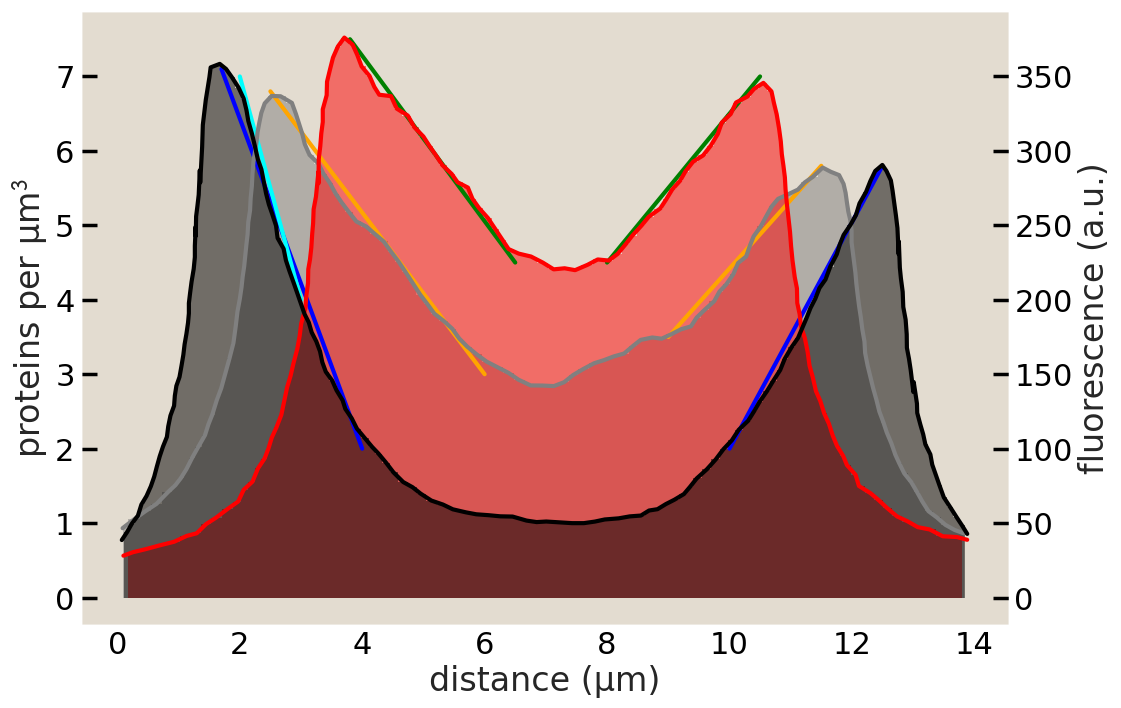

In [119]:
N=1/0.02
fig, ax = plt.subplots(figsize=(12, 8))
plt.plot(pom1_9pt8['x'], pom1_9pt8[' y']/N, color='grey', zorder=10000)
plt.plot(pom1_7pt6['x'], pom1_7pt6[' y']/N, color='r', zorder=10001)
plt.plot(pom1_11pt5['x'], pom1_11pt5[' y']/N, color='k', zorder=10002)
for i in range(len(rectlens_9pt8)):
#     plt.hlines(specy[i+1], rectpts[i], rectpts[i+1], lw=0.5)
#     plt.vlines(rectpts[i], 0, max(specy[i], specy[i+1]), lw=0.5)
#     plt.vlines(rectpts[i+1], 0, max(specy[i+1], specy[i+2]), lw=0.5)
    plt.fill_between([rectpts_9pt8[i], rectpts_9pt8[i+1]],
                     [0, 0],
                     [np.array(pom1_9pt8[' y']/N)[i+1], np.array(pom1_9pt8[' y']/N)[i+1]],
                     color = 'grey', alpha=0.5,linewidth=0)
plt.fill_between([np.array(pom1_9pt8['x'])[0], rectpts_9pt8[0]],
                     [0, 0],
                     [np.array(pom1_9pt8[' y']/N)[0], np.array(pom1_9pt8[' y']/N)[0]],
                     color = 'grey', alpha=0.5, linewidth=0)
plt.fill_between([rectpts_9pt8[-1], np.array(pom1_9pt8['x'])[-1]],
                     [0, 0],
                     [np.array(pom1_9pt8[' y']/N)[-1], np.array(pom1_9pt8[' y']/N)[-1]],
                     color = 'grey', alpha=0.5, linewidth=0)
for i in range(len(rectlens_7pt6)):    
    plt.fill_between([rectpts_7pt6[i], rectpts_7pt6[i+1]],
                     [0, 0],
                     [np.array(pom1_7pt6[' y']/N)[i+1], np.array(pom1_7pt6[' y']/N)[i+1]],
                     color = 'r', alpha=0.5,linewidth=0)
for i in range(len(rectlens_11pt5)):    
    plt.fill_between([rectpts_11pt5[i], rectpts_11pt5[i+1]],
                     [0, 0],
                     [np.array(pom1_11pt5[' y']/N)[i+1], np.array(pom1_11pt5[' y']/N)[i+1]],
                     color = 'k', alpha=0.5,linewidth=0)
#plt.plot([1.7, 4],[7, 1.5], c='blue')
plt.plot([1.7, 4],[7.1, 2], c='blue')
plt.plot([2, 3],[7, 4], c='cyan')
plt.plot([10, 12.5],[2, 5.8], c='blue')
plt.plot([2.5, 6],[6.8, 3], c='orange')
plt.plot([9, 11.5],[3.5, 5.8], c='orange')
plt.plot([3.8, 6.5],[7.5, 4.5], c='green')
plt.plot([8, 10.5],[4.5, 7], c='green')

ax.set_ylabel(f'proteins per µm$^3$')
ax.set_xlabel('distance (µm)')

# right axis (scaled)
ax2 = ax.twinx()
ax2.set_ylabel('fluorescence (a.u.)')

# link the limits so they match scaling
ymin, ymax = ax.get_ylim()
ax2.set_ylim(ymin * N, ymax * N)

#plt.xticks(fontsize=12)
#plt.yticks(fontsize=12)
#sns.despine(trim=True)
plt.savefig('../data/scaleOfGradCompare/pombemultiSizeCal.pdf', bbox_inches='tight')


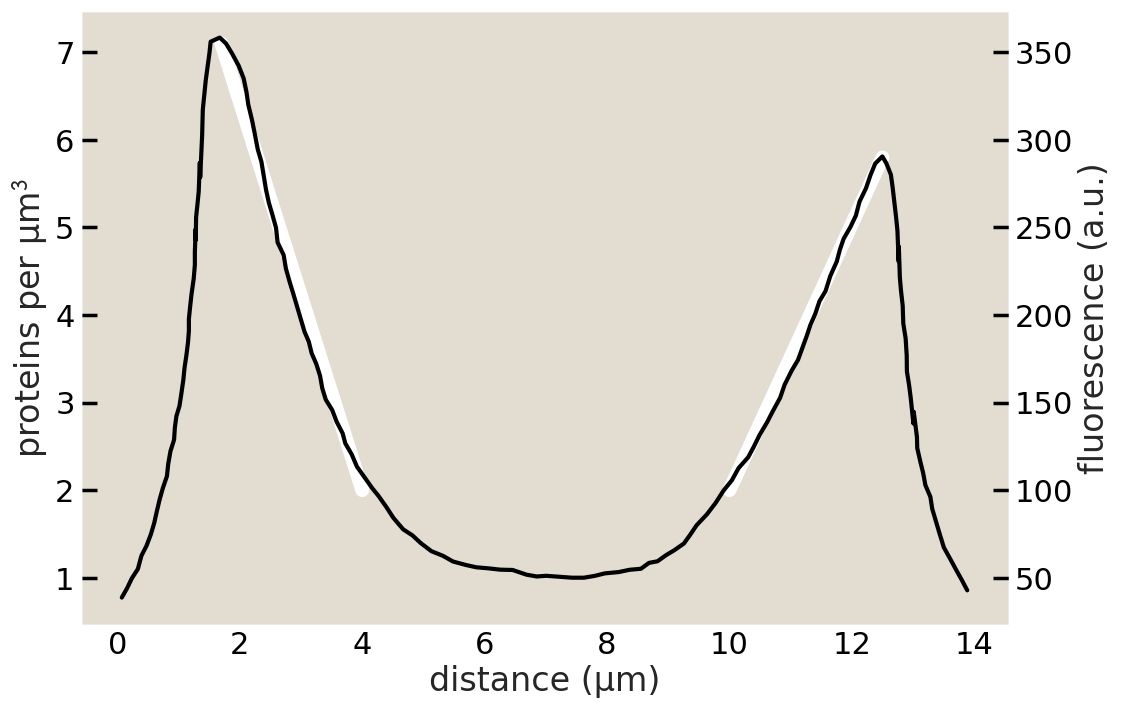

In [118]:
N=1/0.02
fig, ax = plt.subplots(figsize=(12, 8))
plt.plot(pom1_11pt5['x'], pom1_11pt5[' y']/N, color='k', zorder=10002)

plt.plot([1.7, 4],[7.1, 2], c='w', lw=10)
#plt.plot([2, 3],[7, 4], c='cyan')
plt.plot([10, 12.5],[2, 5.8], c='w', lw=10)

ax.set_ylabel(f'proteins per µm$^3$')
ax.set_xlabel('distance (µm)')

# right axis (scaled)
ax2 = ax.twinx()
ax2.set_ylabel('fluorescence (a.u.)')

# link the limits so they match scaling
ymin, ymax = ax.get_ylim()
ax2.set_ylim(ymin * N, ymax * N)

#plt.xticks(fontsize=12)
#plt.yticks(fontsize=12)
#sns.despine(trim=True)
plt.savefig('../data/scaleOfGradCompare/pombe11pt5Cal.pdf', bbox_inches='tight')

In [102]:
print('blue')
print((7.1-2)/(1.7-4))
print((7-4)/(3-2))
print((7-1.5)/(1.7-4))
print((2-5.8)/(10-12.5))
print('orange')
print((6.8-3)/(2.5-6))
print((3.5-5.8)/(9-11.5))
print('green')
print((7.5-4.5)/(3.8-6.5))
print((4.5-7)/(8-10.5))

blue
-2.217391304347826
3.0
-2.3913043478260874
1.52
orange
-1.0857142857142856
0.9199999999999999
green
-1.111111111111111
1.0


In [51]:
#area under the curve
auc = np.sum(np.array(pom1_9pt8[' y'])[1:-1]*rectlens) + np.array(pom1_9pt8[' y'])[0]*(rectpts[0]-np.array(pom1_9pt8['x'])[0]) + np.array(pom1_9pt8[' y'])[-1]*(np.array(pom1_9pt8['x'])[-1]- rectpts[-1])
auc                                                              

np.float64(2534.345860380316)

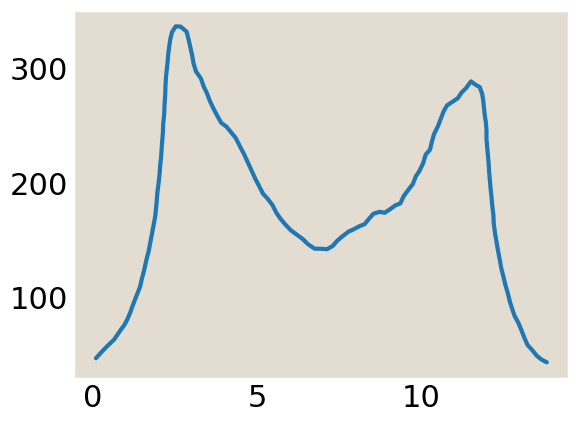

In [14]:
plt.plot(pom1_9pt8['x'], pom1_9pt8[' y'])